[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/225/blob/main/09_data_aggregation/09_3_Agg.ipynb)

# 09.3: `agg()` in Depth

Every groupby example so far has computed one statistic at a time: `groupby(col)[col].mean()` or `.sum()` or `.median()`. But understanding a group usually requires more than one number. The mean tells you where the center is; the standard deviation tells you how spread out the values are; the min and max show the full range. Running three separate groupby calls to get three statistics is tedious and produces three separate results that are awkward to compare.

`agg()` solves this by running multiple aggregation functions in a single call and returning all the results in one DataFrame.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

url = "https://raw.githubusercontent.com/jennybc/gapminder/main/inst/extdata/gapminder.tsv"
df = pd.read_csv(url, sep="\t")
df2007 = df[df["year"] == 2007].copy()
df2007.head()

,country,continent,year,lifeExp,pop,gdpPercap
11,Afghanistan,Asia,2007,43.828,31889923,974.580338
23,Albania,Europe,2007,76.423,3600523,5937.029526
35,Algeria,Africa,2007,72.301,33333216,6223.367465
47,Angola,Africa,2007,42.731,12420476,4797.231267
59,Argentina,Americas,2007,75.320,40301927,12779.379640


## Why one statistic is not enough

The mean life expectancy by continent in 2007 gives a single number per group. But two continents with the same mean can look completely different if one is homogeneous and the other has extreme variation.

In [2]:
df2007.groupby("continent")["lifeExp"].mean().round(1).sort_values(ascending=False)

continent
Oceania     80.7
Europe      77.6
Americas    73.6
Asia        70.7
Africa      54.8
Name: lifeExp, dtype: float64

Europe's mean of about 77.6 years: does that represent a tightly clustered continent, or is there large country-to-country variation? We cannot tell from the mean alone. We need to ask for more at once.

## `agg()` with a list of functions

Passing a list of function names to `agg()` computes all of them for each group and returns a DataFrame with one column per function.

In [3]:
df2007.groupby("continent")["lifeExp"].agg(["mean", "median", "std", "min", "max"]).round(1)

,mean,median,std,min,max
continent,,,,,
Africa,54.8,52.9,9.6,39.6,76.4
Americas,73.6,72.9,4.4,60.9,80.7
Asia,70.7,72.4,8.0,43.8,82.6
Europe,77.6,78.6,3.0,71.8,81.8
Oceania,80.7,80.7,0.7,80.2,81.2


Now the picture is fuller. Europe's mean and median are close together (77.6 and 78.6), and the standard deviation of 2.9 years is the smallest of any continent apart from two-country Oceania; Europe is a tight cluster of similarly long-lived countries. Africa's mean of 54.8 masks a standard deviation of 9.6 and a range from 39.6 to 76.4: enormous variation that makes the mean nearly meaningless as a description of any individual country. Oceania shows two countries only, which explains its tiny std.

This table took one line. Three separate groupby calls would have taken three lines and produced three separate objects to compare.

## Named aggregations: controlling the output

The list syntax works well when you are aggregating a single column. When you want to aggregate multiple columns with different functions and give the output columns meaningful names, the **named aggregation syntax** is cleaner.

The pattern is: `agg(output_name=("source_column", "function"))`.

In [4]:
summary = df2007.groupby("continent").agg(
    avg_life      = ("lifeExp",   "mean"),
    med_life      = ("lifeExp",   "median"),
    life_spread   = ("lifeExp",   "std"),
    avg_gdp       = ("gdpPercap", "mean"),
    total_pop     = ("pop",       "sum"),
    n_countries   = ("country",   "nunique")
).round(1)

summary

,avg_life,med_life,life_spread,avg_gdp,total_pop,n_countries
continent,,,,,,
Africa,54.8,52.9,9.6,3089.0,929539692,52
Americas,73.6,72.9,4.4,11003.0,898871184,25
Asia,70.7,72.4,8.0,12473.0,3811953827,33
Europe,77.6,78.6,3.0,25054.5,586098529,30
Oceania,80.7,80.7,0.7,29810.2,24549947,2


Each keyword argument names the output column on the left and specifies the source column and function on the right. You can mix columns freely: `avg_life` and `life_spread` both come from `lifeExp`, while `avg_gdp` comes from `gdpPercap` and `total_pop` comes from `pop`.

The `"nunique"` function counts distinct values; here it confirms how many countries are in each continent. This is particularly useful when the groupby key is not the same as the column you want to count.

The result is a plain DataFrame. You can sort it, filter it, or pass it directly to a chart.

## `size()` vs `count()`: two ways to count

Counting within groups is common, but there are two different things you might want to count, and they give different answers when nulls are present.

In [5]:
print("size(): counts every row, including nulls:")
print(df2007.groupby("continent").size())
print()
print("count(): counts non-null values per column:")
print(df2007.groupby("continent")["lifeExp"].count())

size(): counts every row, including nulls:
continent
Africa      52
Americas    25
Asia        33
Europe      30
Oceania      2
dtype: int64

count(): counts non-null values per column:
continent
Africa      52
Americas    25
Asia        33
Europe      30
Oceania      2
Name: lifeExp, dtype: int64


With a clean dataset like Gapminder they agree. In a dataset with missing values, `size()` and `count()` diverge: `size()` counts every row in the group regardless of nulls, while `count()` counts only the non-null values in the specified column. Use `size()` when you want to know how many rows are in each group; use `count()` when you want to know how many valid observations you have for a specific column.

## Using the aggregated result in a chart

Because the named-aggregation result is a plain DataFrame, you can reset the index and pass it directly to seaborn.

Text(0, 0.5, 'Continent')

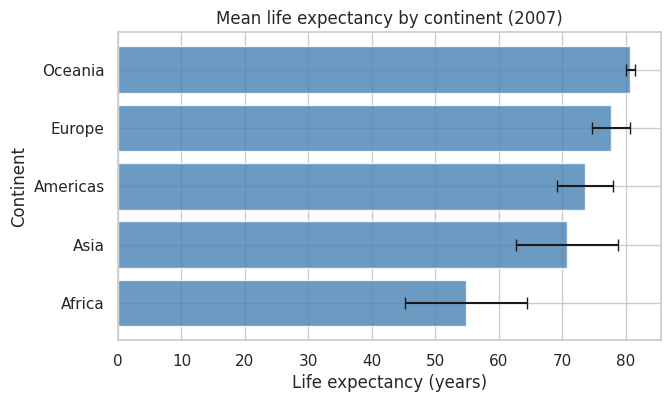

In [6]:
summary_flat = summary.reset_index().sort_values("avg_life")

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(summary_flat["continent"], summary_flat["avg_life"],
        xerr=summary_flat["life_spread"], color="steelblue",
        capsize=4, alpha=0.8)
ax.set_title("Mean life expectancy by continent (2007)")
ax.set_xlabel("Life expectancy (years)")
ax.set_ylabel("Continent")

The error bars represent one standard deviation on each side. Africa's bar is short with wide error bars, showing a low mean and high internal variation. Europe and Oceania have long bars with narrow error bars, reflecting high means and low internal variation. The named aggregation made both the center and the spread available in the same object, so a single chart could show both.

## Which row holds the group maximum?

The aggregations so far answer "how high?" questions: `max()` gives the highest life expectancy in each continent as one number per group. But often the real question is "who?": which country holds that maximum? `max()` returns the value and throws away the row it came from.

`idxmax()` solves this. Called after a groupby, it returns the *index label* of the row where each group's maximum occurs. Passing those labels to `df.loc[]` retrieves the full rows, so the country name, the value, and everything else arrive together. (`idxmin()` does the same for the minimum.)

In [7]:
# Which country has the highest life expectancy in each continent?
top_rows = df2007.loc[df2007.groupby("continent")["lifeExp"].idxmax()]
top_rows[["continent", "country", "lifeExp"]].sort_values("lifeExp", ascending=False)

,continent,country,lifeExp
803,Asia,Japan,82.603
695,Europe,Iceland,81.757
71,Oceania,Australia,81.235
251,Americas,Canada,80.653
1271,Africa,Reunion,76.442


One row per continent: Japan tops Asia at 82.6, Iceland tops Europe, Australia tops Oceania, Canada tops the Americas, and Reunion tops Africa at 76.4. The pattern is worth remembering because it comes up constantly: `groupby()[col].idxmax()` finds where each group peaks, and `df.loc[]` turns those locations back into full rows.

## `nunique()` for counting distinct values within groups

`nunique()` is especially useful when you want to ask "how many distinct values of column A appear within each group of column B?" This type of question does not require any numeric aggregation.

In [8]:
# How many distinct countries appear in each continent across all years?
df.groupby("continent")["country"].nunique().sort_values(ascending=False)

continent
Africa      52
Asia        33
Europe      30
Americas    25
Oceania      2
Name: country, dtype: int64

Africa has 52 distinct countries in the dataset, Asia has 33, the Americas have 25. This confirms the continent sizes we saw in notebook 09.1. Using `nunique()` here is important: `count()` would give us the total number of rows per continent (52 countries × 12 years = 624 rows for Africa), which is a different question entirely.

## What's next

`agg()` reduces each group to one row of summary statistics. But sometimes you want the group-level result aligned back to every original row, not collapsed. Notebook 09.4 introduces `transform()`, which does exactly that: it computes a group statistic and broadcasts it back to every row in the group, preserving the original DataFrame's shape.